# Notification Priority Classification — Modeling

The baseline serves two purposes:
1. A **reference point** to confirm the transformer models actually improve on keyword-matching
2. A **fast, interpretable** model that runs locally in seconds



---

## 1. Imports & Setup

In [1]:
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent
DATA_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'baseline'
FIGURES_DIR  = PROJECT_ROOT / 'results' / 'figures'

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL2ID = {'low': 0, 'medium': 1, 'high': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
LABEL_ORDER   = ['high', 'medium', 'low']
URGENCY_COLORS = {'high': '#E74C3C', 'medium': '#F39C12', 'low': '#2ECC71'}

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13})
print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
train_df = pd.read_csv(DATA_DIR / 'notifications_train.csv')
val_df   = pd.read_csv(DATA_DIR / 'notifications_val.csv')
test_df  = pd.read_csv(DATA_DIR / 'notifications_test.csv')

for df in (train_df, val_df, test_df):
    df['urgency'] = df['urgency'].str.lower().str.strip()

X_train, y_train = train_df['notif_content'].fillna('').tolist(), train_df['urgency'].tolist()
X_val,   y_val   = val_df['notif_content'].fillna('').tolist(),   val_df['urgency'].tolist()
X_test,  y_test  = test_df['notif_content'].fillna('').tolist(),  test_df['urgency'].tolist()

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print('\nUrgency distribution (train):')
print(train_df['urgency'].value_counts())

Train: 531 | Val: 112 | Test: 112

Urgency distribution (train):
urgency
low       205
high      186
medium    140
Name: count, dtype: int64


## 3. TF-IDF Features

We load the vectoriser fitted in notebook 02 to avoid any data leakage.
If it hasn't been saved yet, we re-fit it here.

In [3]:
vectorizer_path = MODELS_DIR / 'tfidf_vectorizer.pkl'

if vectorizer_path.exists():
    with open(vectorizer_path, 'rb') as f:
        tfidf = pickle.load(f)
    print(f'Vectoriser loaded from {vectorizer_path}')
else:
    print('Vectoriser not found — fitting now (run notebook 02 first for consistency).')
    tfidf = TfidfVectorizer(
        ngram_range=(1, 2), max_features=500,
        sublinear_tf=True, min_df=2,
    )
    tfidf.fit(X_train)
    with open(vectorizer_path, 'wb') as f:
        pickle.dump(tfidf, f)
    print(f'Vectoriser fitted and saved to {vectorizer_path}')

X_train_tfidf = tfidf.transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Feature matrix shapes — train: {X_train_tfidf.shape}, val: {X_val_tfidf.shape}, test: {X_test_tfidf.shape}')

Vectoriser loaded from /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/models/tfidf_vectorizer.pkl
Feature matrix shapes — train: (531, 500), val: (112, 500), test: (112, 500)


---
## 4. Baseline: Logistic Regression

We use `class_weight='balanced'` so the model does not favour the slightly
over-represented Low class (38.4% of samples).  `max_iter=1000` ensures
convergence on the sparse TF-IDF features.

In [4]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    C=1.0,             # default regularisation strength
)
lr.fit(X_train_tfidf, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


### 4.1 Validation Performance

In [5]:
val_preds = lr.predict(X_val_tfidf)
val_probs = lr.predict_proba(X_val_tfidf)   # shape (n_val, 3)

val_macro_f1 = f1_score(y_val, val_preds, average='macro')
val_accuracy = accuracy_score(y_val, val_preds)

print(f'Validation macro-F1 : {val_macro_f1:.4f}')
print(f'Validation accuracy : {val_accuracy:.4f}')
print()
print('Per-class classification report (validation set):')
print(classification_report(y_val, val_preds, target_names=['high', 'low', 'medium']))

Validation macro-F1 : 0.8262
Validation accuracy : 0.8304

Per-class classification report (validation set):
              precision    recall  f1-score   support

        high       0.85      0.90      0.88        39
         low       0.87      0.79      0.83        43
      medium       0.75      0.80      0.77        30

    accuracy                           0.83       112
   macro avg       0.83      0.83      0.83       112
weighted avg       0.83      0.83      0.83       112



### 4.2 Test Performance

In [6]:
test_preds = lr.predict(X_test_tfidf)
test_probs = lr.predict_proba(X_test_tfidf)   # columns ordered by lr.classes_

test_macro_f1 = f1_score(y_test, test_preds, average='macro')
test_accuracy = accuracy_score(y_test, test_preds)

print(f'Test macro-F1 : {test_macro_f1:.4f}')
print(f'Test accuracy : {test_accuracy:.4f}')
print()
print('Per-class classification report (test set):')
print(classification_report(y_test, test_preds, target_names=['high', 'low', 'medium']))

Test macro-F1 : 0.8527
Test accuracy : 0.8571

Per-class classification report (test set):
              precision    recall  f1-score   support

        high       0.92      0.92      0.92        39
         low       0.90      0.81      0.85        43
      medium       0.74      0.83      0.78        30

    accuracy                           0.86       112
   macro avg       0.85      0.86      0.85       112
weighted avg       0.86      0.86      0.86       112



### 4.3 Confusion Matrix

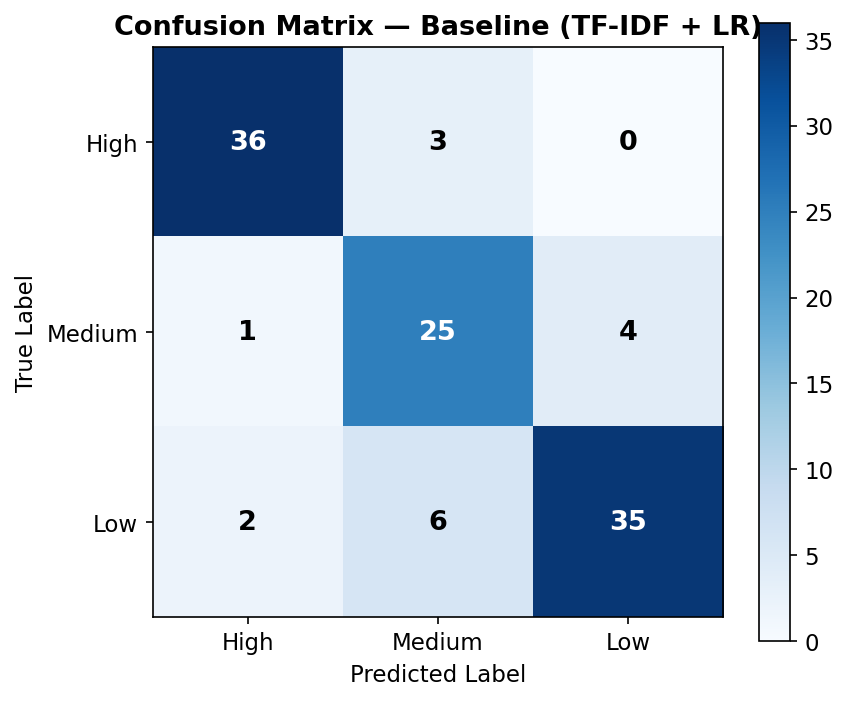

Figure 10 saved.


In [7]:
# lr.classes_ tells us which column in predict_proba corresponds to which label
classes = list(lr.classes_)

cm = confusion_matrix(y_test, test_preds, labels=LABEL_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

tick_labels = ['High', 'Medium', 'Low']
ax.set_xticks(range(3));  ax.set_xticklabels(tick_labels)
ax.set_yticks(range(3));  ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted Label');  ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Baseline (TF-IDF + LR)', fontweight='bold')

# Annotate cells
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

plt.tight_layout()
for ext in ('svg', 'png', 'pdf'):
    fig.savefig(FIGURES_DIR / f'fig10_baseline_confusion_matrix.{ext}',
                bbox_inches='tight', format=ext)
plt.show()
print('Figure 10 saved.')

---
## 5. Save Baseline Model & Results

We save the model and its test-set predictions in the **same schema** used by
`scripts/train_transformer.py`, so `notebooks/04_evaluation.ipynb` can load
all models with identical code.

In [8]:
# Save trained model
model_path = MODELS_DIR / 'baseline_lr.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(lr, f)
print(f'Model saved -> {model_path}')

# Save val metrics JSON
metrics = {
    'model':          'TF-IDF + Logistic Regression',
    'val_macro_f1':   round(val_macro_f1, 4),
    'val_accuracy':   round(val_accuracy, 4),
    'test_macro_f1':  round(test_macro_f1, 4),
    'test_accuracy':  round(test_accuracy, 4),
    'hyperparams': {
        'vectorizer':    'TfidfVectorizer(ngram_range=(1,2), max_features=500, sublinear_tf=True)',
        'classifier':    'LogisticRegression(C=1.0, class_weight=balanced, max_iter=1000)',
    },
}
metrics_path = RESULTS_DIR / 'val_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'Metrics saved -> {metrics_path}')

# Save test predictions — columns match train_transformer.py output exactly
# lr.classes_ may not be in the order [low, medium, high], so we re-index
col_low    = classes.index('low')
col_medium = classes.index('medium')
col_high   = classes.index('high')

pred_df = pd.DataFrame({
    'text':        X_test,
    'true_label':  y_test,
    'pred_label':  test_preds,
    'prob_low':    test_probs[:, col_low],
    'prob_medium': test_probs[:, col_medium],
    'prob_high':   test_probs[:, col_high],
})
preds_path = RESULTS_DIR / 'test_predictions.csv'
pred_df.to_csv(preds_path, index=False)
print(f'Predictions saved -> {preds_path}')

Model saved -> /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/models/baseline_lr.pkl
Metrics saved -> /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/results/baseline/val_metrics.json
Predictions saved -> /Users/denis/Desktop/NLP-final-project/Notification-Priority-Classification-Using-Semantic-Analysis/results/baseline/test_predictions.csv


---
## 6. Baseline Summary

Key numbers for the paper (Week 8 / Section III).

In [9]:
print('=' * 50)
print('BASELINE MODEL SUMMARY')
print('=' * 50)
print(f'  Model      : TF-IDF (unigrams+bigrams, 500 feats)')
print(f'               + Logistic Regression (balanced)')
print()
print(f'  Val  macro-F1 : {val_macro_f1:.4f}')
print(f'  Val  accuracy : {val_accuracy:.4f}')
print(f'  Test macro-F1 : {test_macro_f1:.4f}')
print(f'  Test accuracy : {test_accuracy:.4f}')
print()
print('  Saved artefacts:')
print(f'    models/baseline_lr.pkl')
print(f'    results/baseline/val_metrics.json')
print(f'    results/baseline/test_predictions.csv')
print(f'    results/figures/fig10_baseline_confusion_matrix.*')
print()
print('  Next: run notebooks/04_evaluation.ipynb once')
print('  BERT/RoBERTa results arrive from the cluster.')
print('=' * 50)

BASELINE MODEL SUMMARY
  Model      : TF-IDF (unigrams+bigrams, 500 feats)
               + Logistic Regression (balanced)

  Val  macro-F1 : 0.8262
  Val  accuracy : 0.8304
  Test macro-F1 : 0.8527
  Test accuracy : 0.8571

  Saved artefacts:
    models/baseline_lr.pkl
    results/baseline/val_metrics.json
    results/baseline/test_predictions.csv
    results/figures/fig10_baseline_confusion_matrix.*

  Next: run notebooks/04_evaluation.ipynb once
  BERT/RoBERTa results arrive from the cluster.
